## Importing libraries

In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("yusufmurtaza01/chest-xray-pneumonia-balanced-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'chest-xray-pneumonia-balanced-dataset' dataset.
Path to dataset files: /kaggle/input/chest-xray-pneumonia-balanced-dataset


In [2]:
import os

# List the contents of the downloaded dataset directory
dataset_contents = os.listdir(path)

print(f"Contents of {path}:")
for item in dataset_contents:
    print(item)


Contents of /kaggle/input/chest-xray-pneumonia-balanced-dataset:
val
test
train


In [3]:
pip install torch torchvision transformers datasets scikit-learn matplotlib

In [4]:
pip install transformers

In [5]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from torchvision import transforms
from PIL import Image
import os
from transformers import ViTImageProcessor, ViTForImageClassification

from sklearn.metrics import accuracy_score, classification_report

In [6]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


### Data set load and analyzer

In [8]:
data_dir = "/kaggle/input/chest-xray-pneumonia-balanced-dataset"

def count_images(folder):
    counts = {}
    for label in os.listdir(folder):
        path = os.path.join(folder, label)
        if os.path.isdir(path):
            counts[label] = len(os.listdir(path))
    return counts

train_counts = count_images(os.path.join(data_dir, "train"))
val_counts = count_images(os.path.join(data_dir, "val"))
test_counts = count_images(os.path.join(data_dir, "test"))

print("Train distribution:", train_counts)
print("Validation distribution:", val_counts)
print("Test distribution:", test_counts)

Train distribution: {'PNEUMONIA': 3400, 'NORMAL': 3400}
Validation distribution: {'PNEUMONIA': 850, 'NORMAL': 850}
Test distribution: {'PNEUMONIA': 15, 'NORMAL': 15}


In [9]:
from transformers import ViTImageProcessor

processor = ViTImageProcessor.from_pretrained("google/vit-base-patch16-224")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/160 [00:00<?, ?B/s]

In [10]:
print(processor)

ViTImageProcessor {
  "do_convert_rgb": null,
  "do_normalize": true,
  "do_rescale": true,
  "do_resize": true,
  "image_mean": [
    0.5,
    0.5,
    0.5
  ],
  "image_processor_type": "ViTImageProcessor",
  "image_std": [
    0.5,
    0.5,
    0.5
  ],
  "resample": 2,
  "rescale_factor": 0.00392156862745098,
  "size": {
    "height": 224,
    "width": 224
  }
}



In [11]:
from PIL import Image

img_path = os.path.join(data_dir, "train", "PNEUMONIA", os.listdir(os.path.join(data_dir, "train", "PNEUMONIA"))[0])

image = Image.open(img_path).convert("RGB")

inputs = processor(images=image, return_tensors="pt")

print(inputs["pixel_values"].shape)

torch.Size([1, 3, 224, 224])


In [12]:
class XRayDataset(Dataset):
    def __init__(self, data_dir, split, processor):
        self.data = []
        self.processor = processor

        split_path = os.path.join(data_dir, split)

        for label in os.listdir(split_path):
            label_path = os.path.join(split_path, label)

            if label == "NORMAL":
                label_id = 0
            else:
                label_id = 1

            for img_name in os.listdir(label_path):
                img_path = os.path.join(label_path, img_name)
                self.data.append((img_path, label_id))

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        img_path, label = self.data[idx]

        image = Image.open(img_path).convert("RGB")

        inputs = self.processor(images=image, return_tensors="pt")

        # remove batch dimension
        pixel_values = inputs["pixel_values"].squeeze(0)

        return pixel_values, torch.tensor(label)

In [13]:
train_dataset = XRayDataset(data_dir, "train", processor)
val_dataset = XRayDataset(data_dir, "val", processor)
test_dataset = XRayDataset(data_dir, "test", processor)

print("Train size:", len(train_dataset))
print("Validation size:", len(val_dataset))
print("Test size:", len(test_dataset))

Train size: 6800
Validation size: 1700
Test size: 30


In [14]:
train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=8, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=8, shuffle=False)

In [15]:
images, labels = next(iter(train_loader))

print("Images shape:", images.shape)
print("Labels shape:", labels.shape)

Images shape: torch.Size([8, 3, 224, 224])
Labels shape: torch.Size([8])


### Model loading and Finetuning

In [ ]:
# model = ViTForImageClassification.from_pretrained(
#     "google/vit-base-patch16-224"
# )

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

In [ ]:
# model.classifier = nn.Linear(model.config.hidden_size, 2)
# model.to(device)
# print(model.classifier)

Linear(in_features=768, out_features=2, bias=True)


In [ ]:
# from sklearn.utils.class_weight import compute_class_weight
# import numpy as np

# labels = [label for _, label in train_dataset.data]

# class_weights = compute_class_weight(
#     class_weight="balanced",
#     classes=np.unique(labels),
#     y=labels
# )

# class_weights = torch.tensor(class_weights, dtype=torch.float).to(device)

# print("Class weights:", class_weights)

Class weights: tensor([1.9448, 0.6730], device='cuda:0')


In [ ]:
# criterion = nn.CrossEntropyLoss(weight=class_weights)

In [ ]:
# optimizer = torch.optim.AdamW(model.parameters(), lr=5e-5)

### Training and evaluation

In [ ]:
# def train_one_epoch(model, loader, optimizer, criterion, device):
#     model.train()
#     total_loss = 0

#     for images, labels in loader:
#         images = images.to(device)
#         labels = labels.to(device)

#         # Forward pass
#         outputs = model(pixel_values=images)
#         logits = outputs.logits

#         # Loss
#         loss = criterion(logits, labels)

#         # Backprop
#         optimizer.zero_grad()
#         loss.backward()
#         optimizer.step()

#         total_loss += loss.item()

#     return total_loss / len(loader)

In [ ]:
# def evaluate(model, loader, device):
#     model.eval()
#     all_preds = []
#     all_labels = []

#     with torch.no_grad():
#         for images, labels in loader:
#             images = images.to(device)

#             outputs = model(pixel_values=images)
#             logits = outputs.logits

#             preds = torch.argmax(logits, dim=1).cpu().numpy()

#             all_preds.extend(preds)
#             all_labels.extend(labels.numpy())

#     acc = accuracy_score(all_labels, all_preds)
#     return acc

In [ ]:
# epochs = 3  # start small

# for epoch in range(epochs):
#     train_loss = train_one_epoch(model, train_loader, optimizer, criterion, device)
#     val_acc = evaluate(model, test_loader, device)

#     print(f"Epoch {epoch+1}/{epochs}")
#     print(f"Train Loss: {train_loss:.4f}")
#     print(f"Validation Accuracy: {val_acc:.4f}")

Epoch 1/3
Train Loss: 0.1128
Validation Accuracy: 0.7869
Epoch 2/3
Train Loss: 0.0368
Validation Accuracy: 0.8750
Epoch 3/3
Train Loss: 0.0429
Validation Accuracy: 0.7580


### Augmentation while training

In [ ]:
# from torchvision import transforms

# # Augmentation for training images
# train_transforms = transforms.Compose([
#     transforms.RandomHorizontalFlip(p=0.5),  # flip half of images
#     transforms.RandomRotation(degrees=10),   # small rotation
#     transforms.ColorJitter(brightness=0.1, contrast=0.1) # slight brightness/contrast change
#     # transforms.ToTensor(),                    # convert to tensor
#     # transforms.Normalize(mean=[0.5,0.5,0.5], std=[0.5,0.5,0.5])  # match ViT preprocessing
# ])

# # Validation / Test (no augmentation)
# Test_transforms = transforms.Compose([
# #     transforms.ToTensor(),
# #     transforms.Normalize(mean=[0.5,0.5,0.5], std=[0.5,0.5,0.5])
# ])

In [ ]:
# class XRayDatasetBalanced(Dataset):
#     def __init__(self, data_dir, split, processor, transform=None, oversample_ratio=0.3):
#         self.data = []
#         self.processor = processor
#         self.transform = transform

#         split_path = os.path.join(data_dir, split)

#         normal = []
#         pneumonia = []

#         for label in os.listdir(split_path):
#             label_path = os.path.join(split_path, label)

#             label_id = 0 if label == "NORMAL" else 1

#             for img_name in os.listdir(label_path):
#                 img_path = os.path.join(label_path, img_name)

#                 if label_id == 0:
#                     normal.append((img_path, label_id))
#                 else:
#                     pneumonia.append((img_path, label_id))

#         # 🔥 Controlled oversampling (NOT full balancing)
#         extra_count = int(len(normal) * oversample_ratio)  # e.g. 30% more NORMAL

#         normal_extra = random.choices(normal, k=extra_count)

#         # Combine data
#         self.data = pneumonia + normal + normal_extra

#     def __len__(self):
#         return len(self.data)

#     def __getitem__(self, idx):
#         img_path, label = self.data[idx]
#         image = Image.open(img_path).convert("RGB")

#         # Apply augmentation ONLY to NORMAL class
#         if self.transform and label == 0:
#             image = self.transform(image)

#         inputs = self.processor(images=image, return_tensors="pt")
#         pixel_values = inputs["pixel_values"].squeeze(0)

#         return pixel_values, torch.tensor(label)

In [ ]:
# from collections import Counter
# train_dataset_aug = XRayDatasetBalanced(
#     data_dir, "train", processor, transform=train_transforms
# )

# # # ✅ Use normal dataset for test (no oversampling, no augmentation)
# # test_dataset = XRayDataset(
# #     data_dir, "test", processor, transform=None
# # )from collections import Counter

# labels = [label for _, label in train_dataset_aug.data]
# counts = Counter(labels)

# print("After Augmentation:")
# print("NORMAL (0):", counts[0])
# print("PNEUMONIA (1):", counts[1])

# train_loader_aug = DataLoader(train_dataset_aug, batch_size=8, shuffle=True)
# # test_loader = DataLoader(test_dataset, batch_size=8, shuffle=False)

After Augmentation:
NORMAL (0): 1743
PNEUMONIA (1): 3875


In [ ]:
# images, labels = next(iter(train_loader_aug))
# print("Images shape:", images.shape)
# print("Labels shape:", labels.shape)

Images shape: torch.Size([8, 3, 224, 224])
Labels shape: torch.Size([8])


### Training after augmentation

In [ ]:
# def train_one_epoch(model, loader, optimizer, criterion, device):
#     model.train()
#     total_loss = 0

#     for images, labels in loader:
#         images = images.to(device)
#         labels = labels.to(device)

#         # Forward pass
#         outputs = model(pixel_values=images)
#         logits = outputs.logits

#         # Loss
#         loss = criterion(logits, labels)

#         # Backprop
#         optimizer.zero_grad()
#         loss.backward()
#         optimizer.step()

#         total_loss += loss.item()

#     return total_loss / len(loader)

In [ ]:
# def evaluate(model, loader, device):
#     model.eval()
#     all_preds = []
#     all_labels = []

#     with torch.no_grad():
#         for images, labels in loader:
#             images = images.to(device)

#             outputs = model(pixel_values=images)
#             logits = outputs.logits

#             preds = torch.argmax(logits, dim=1).cpu().numpy()

#             all_preds.extend(preds)
#             all_labels.extend(labels.numpy())

#     acc = accuracy_score(all_labels, all_preds)
#     return acc

In [ ]:
# epochs = 3  # start small

# for epoch in range(epochs):
#     train_loss = train_one_epoch(model, train_loader_aug, optimizer, criterion, device)
#     val_acc = evaluate(model, test_loader_aug, device)

#     print(f"Epoch {epoch+1}/{epochs}")
#     print(f"Train Loss: {train_loss:.4f}")
#     print(f"Validation Accuracy: {val_acc:.4f}")

Epoch 1/3
Train Loss: 0.0511
Validation Accuracy: 0.8189
Epoch 2/3
Train Loss: 0.0506
Validation Accuracy: 0.8750
Epoch 3/3
Train Loss: 0.0331
Validation Accuracy: 0.8397


Confusion Matrix:
 [[139  95]
 [  5 385]]


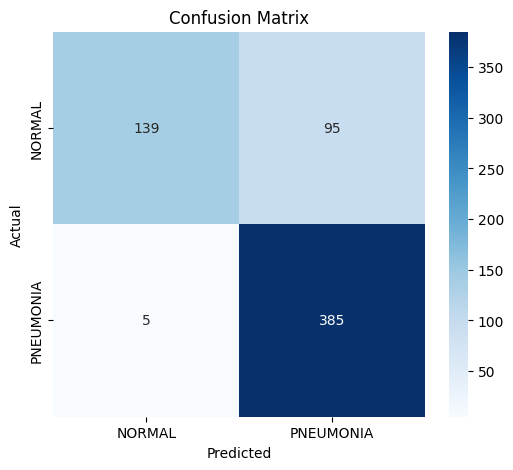

Classification Report:
               precision    recall  f1-score   support

      NORMAL       0.97      0.59      0.74       234
   PNEUMONIA       0.80      0.99      0.89       390

    accuracy                           0.84       624
   macro avg       0.88      0.79      0.81       624
weighted avg       0.86      0.84      0.83       624



In [ ]:
# from sklearn.metrics import confusion_matrix, classification_report
# import seaborn as sns
# import matplotlib.pyplot as plt
# import torch

# # Make sure model is in evaluation mode
# model.eval()

# all_preds = []
# all_labels = []

# # Collect predictions and true labels
# with torch.no_grad():
#     for images, labels in test_loader:  # or test_loader_aug if using augmentation
#         images = images.to(device)
#         labels = labels.to(device)

#         outputs = model(pixel_values=images)
#         logits = outputs.logits

#         preds = torch.argmax(logits, dim=1)

#         all_preds.extend(preds.cpu().numpy())
#         all_labels.extend(labels.cpu().numpy())

# # Confusion matrix
# cm = confusion_matrix(all_labels, all_preds)
# print("Confusion Matrix:\n", cm)

# # Plot confusion matrix
# plt.figure(figsize=(6,5))
# sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["NORMAL","PNEUMONIA"], yticklabels=["NORMAL","PNEUMONIA"])
# plt.xlabel("Predicted")
# plt.ylabel("Actual")
# plt.title("Confusion Matrix")
# plt.show()

# # Classification report: precision, recall, F1-score
# report = classification_report(all_labels, all_preds, target_names=["NORMAL","PNEUMONIA"])
# print("Classification Report:\n", report)

In [ ]:
# model.eval()
# correct = 0
# total = 0

# with torch.no_grad():
#     for images, labels in train_loader_aug:
#         images = images.to(device)
#         labels = labels.to(device)
#         outputs = model(pixel_values=images)
#         preds = torch.argmax(outputs.logits, dim=1)
#         correct += (preds == labels).sum().item()
#         total += labels.size(0)

# train_accuracy = correct / total
# print("Training Accuracy:", train_accuracy)

Training Accuracy: 0.9948236196319018


In [ ]:
# torch.save(model, "vit_pneumonia_model.pth")

### Qlora finetuning

In [16]:
import torch
from transformers import ViTForImageClassification, ViTImageProcessor, BitsAndBytesConfig
from peft import LoraConfig, get_peft_model, prepare_model_for_kbit_training
from torch.utils.data import DataLoader
import torch.nn as nn
import torch.optim as optim

# ---------------------------
# 1️⃣ 4-bit Quantization Config
# ---------------------------
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.bfloat16,
    bnb_4bit_use_double_quant=True,
)


In [17]:
!pip install -U bitsandbytes>=0.46.1

In [18]:
# ---------------------------
# 2️⃣ Load pre-trained ViT with 4-bit
# ---------------------------
model_name = "google/vit-base-patch16-224"
model = ViTForImageClassification.from_pretrained(
    model_name,
    num_labels=2,  # pneumonia vs normal
    quantization_config=bnb_config,
    device_map="auto"
)


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

In [19]:
# ---------------------------
# 3️⃣ Prepare model for k-bit training
# ---------------------------
model = prepare_model_for_kbit_training(model)


In [20]:

# ---------------------------
# 4️⃣ LoRA Adapter Config
# ---------------------------
lora_config = LoraConfig(
    r=8,
    lora_alpha=16,
    target_modules=["query", "value"],  # Vision attention proj layers
    lora_dropout=0.05,
    bias="none"
)


In [21]:
# ---------------------------
# 5️⃣ Apply LoRA adapters
# ---------------------------
model = get_peft_model(model, lora_config)

# ---------------------------
# 6️⃣ Processor and DataLoader
# ---------------------------
processor = ViTImageProcessor.from_pretrained(model_name)


In [22]:
from torch import nn

model.classifier = nn.Linear(model.config.hidden_size, 2)
model.to(device)

PeftModel(
  (base_model): LoraModel(
    (model): ViTForImageClassification(
      (vit): ViTModel(
        (embeddings): ViTEmbeddings(
          (patch_embeddings): ViTPatchEmbeddings(
            (projection): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
          )
          (dropout): Dropout(p=0.0, inplace=False)
        )
        (encoder): ViTEncoder(
          (layer): ModuleList(
            (0-11): 12 x ViTLayer(
              (attention): ViTAttention(
                (attention): ViTSelfAttention(
                  (query): lora.Linear4bit(
                    (base_layer): Linear4bit(in_features=768, out_features=768, bias=True)
                    (lora_dropout): ModuleDict(
                      (default): Dropout(p=0.05, inplace=False)
                    )
                    (lora_A): ModuleDict(
                      (default): Linear(in_features=768, out_features=8, bias=False)
                    )
                    (lora_B): ModuleDict(
              

In [23]:
# After creating LoRA/PEFT model
from torch import nn
import torch

# 1️⃣ Make sure classifier matches number of classes
model.base_model.model.classifier = nn.Linear(model.base_model.model.config.hidden_size, 2).to(device)

# 2️⃣ Define weights for the 2 classes
class_weights = torch.tensor([1.9448, 0.6730]).to(device)
criterion = nn.CrossEntropyLoss(weight=class_weights)

In [24]:
optimizer = optim.AdamW(model.parameters(), lr=5e-5)

/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:1181: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)


Epoch 1/2, Train Loss: 0.1738, Train Acc: 0.8821, Val Loss: 0.0914, Val Acc: 0.9559
Epoch 2/2, Train Loss: 0.0604, Train Acc: 0.9718, Val Loss: 0.0792, Val Acc: 0.9682


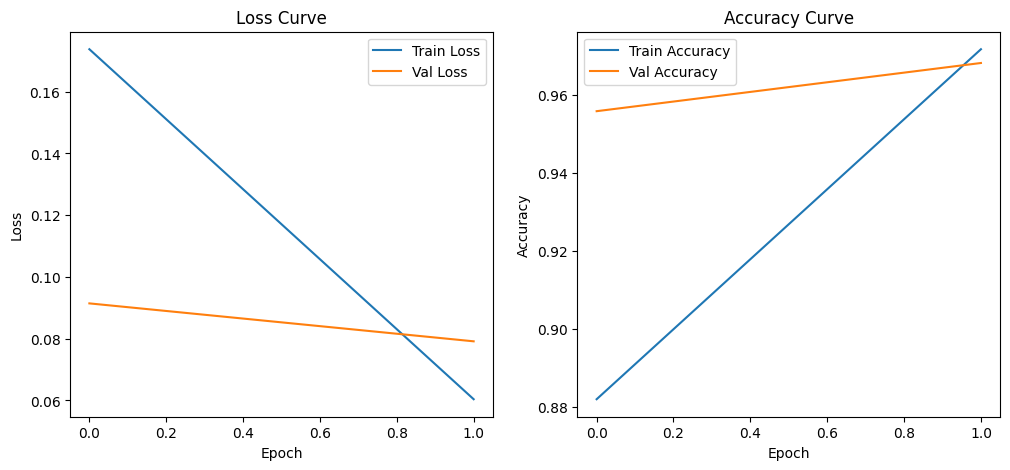

In [25]:
import matplotlib.pyplot as plt

device = "cuda" if torch.cuda.is_available() else "cpu"
model.to(device)

epochs = 2

train_losses = []
train_accuracies = []
val_losses = []
val_accuracies = []

for epoch in range(epochs):
    model.train()
    total_loss = 0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        outputs = model(pixel_values=images).logits
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    avg_train_loss = total_loss / len(train_loader)
    train_acc = correct / total
    train_losses.append(avg_train_loss)
    train_accuracies.append(train_acc)

    # Validation
    model.eval()
    val_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(pixel_values=images).logits
            loss = criterion(outputs, labels)
            val_loss += loss.item()

            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    avg_val_loss = val_loss / len(val_loader)
    val_acc = correct / total
    val_losses.append(avg_val_loss)
    val_accuracies.append(val_acc)

    print(f"Epoch {epoch+1}/{epochs}, Train Loss: {avg_train_loss:.4f}, Train Acc: {train_acc:.4f}, Val Loss: {avg_val_loss:.4f}, Val Acc: {val_acc:.4f}")

# Plotting
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss Curve")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(train_accuracies, label="Train Accuracy")
plt.plot(val_accuracies, label="Val Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy Curve")
plt.legend()

plt.show()

In [26]:
from sklearn.metrics import confusion_matrix

In [27]:
def evaluate(model, loader, device):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)

            # For PEFT/QLoRA, outputs may be inside base_model
            outputs = model(pixel_values=images)
            if hasattr(outputs, "logits"):
                logits = outputs.logits
            else:
                logits = outputs  # fallback

            preds = torch.argmax(logits, dim=1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(labels.cpu().numpy())

    acc = accuracy_score(all_labels, all_preds)

    # Confusion matrix
    cm = confusion_matrix(all_labels, all_preds)

    return acc, cm

In [28]:
# Training accuracy
train_acc, _ = evaluate(model, train_loader, device)

# Test accuracy + confusion matrix
test_acc, cm = evaluate(model, test_loader, device)

print("Training Accuracy:", train_acc)
print("Test Accuracy:", test_acc)

Training Accuracy: 0.9769117647058824
Test Accuracy: 1.0


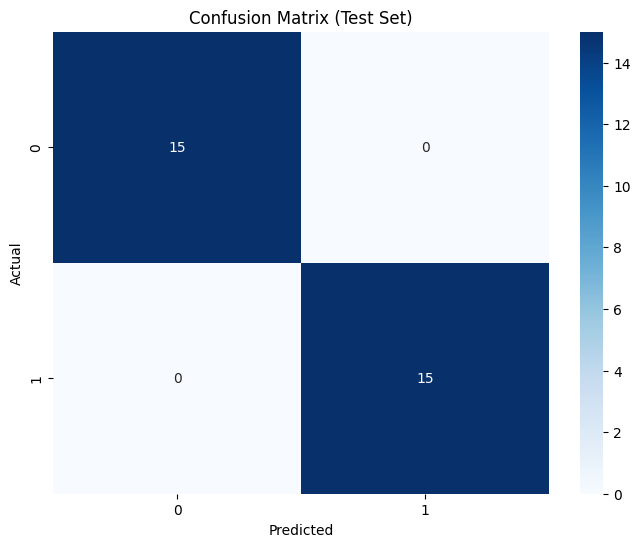

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Assuming cm is a 2D NumPy array or can be converted to one
cm_array = np.array(cm)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_array, annot=True, fmt='d', cmap='Blues', cbar=True)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix (Test Set)')
plt.show()

In [30]:
import torch

# Save only the weights
torch.save(model.state_dict(), "vit_pneumonia_model_weights.pth")